In [1]:
# 1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, validation_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, roc_auc_score
from imblearn.over_sampling import SMOTE

In [2]:
# 2. Load data
df = pd.read_csv("2_preprocessed_encoded.csv")  # Replace with your dataset
X = df.drop("target", axis=1)
y = df["target"]


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)


In [4]:
# 4. Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Apply SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# 6. Initialize Random Forest
rf = RandomForestClassifier(random_state=42)

In [5]:
# 7. Cross-validation
cv_scores = cross_val_score(rf, X_train_resampled, y_train_resampled, cv=10, scoring='accuracy')
print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

CV Scores: [0.82485685 0.81795217 0.82435163 0.91815426 0.93026781 0.93009938
 0.93329965 0.92487788 0.93043625 0.93734209]
Mean CV Accuracy: 0.8971637979632667


In [6]:
# 8. Hyperparameter Tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}
grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_resampled, y_train_resampled)
print("Best Parameters:", grid.best_params_)


Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [8]:
# 10. Train Final Model
rf_final = RandomForestClassifier(**grid.best_params_, random_state=42)
rf_final.fit(X_train_resampled, y_train_resampled)

# 11. Evaluate on Test Set
y_pred = rf_final.predict(X_test_scaled)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Test Accuracy:", accuracy_score(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.89      0.89      7422
           1       0.66      0.68      0.67      2336

    accuracy                           0.84      9758
   macro avg       0.78      0.79      0.78      9758
weighted avg       0.84      0.84      0.84      9758

Confusion Matrix:
 [[6603  819]
 [ 737 1599]]
Test Accuracy: 0.8405410944865751


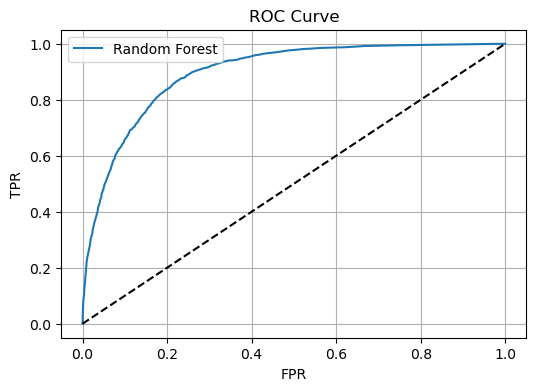

ROC-AUC Score: 0.8963346370748938


In [9]:
# 12. ROC Curve
y_prob = rf_final.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.grid()
plt.legend()
plt.show()
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))